In [ ]:
"""
1. Setup and Data Preparation:
Import necessary libraries such as `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`.
Load the dataset for regression analysis.
Conduct exploratory data analysis (EDA) to understand the dataset.
Preprocess the data by handling missing values, encoding categorical variables, and normalizing/standardizing features if needed.
"""

'\n1. Setup and Data Preparation:\nImport necessary libraries such as `pandas`, `matplotlib`, `seaborn`, and `scikit-learn`.\nLoad the dataset for regression analysis.\nConduct exploratory data analysis (EDA) to understand the dataset.\nPreprocess the data by handling missing values, encoding categorical variables, and normalizing/standardizing features if needed.\n'

In [ ]:
# 1.1 Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1.2 Load the dataset for regression analysis.
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
"""
About Dataset
Context
Machine Learning with R by Brett Lantz is a book that provides an introduction to
machine learning using R. As far as I can tell,
Packt Publishing does not make its datasets available online unless you buy the book
and create a user account
which can be a problem if you are checking the
book out from the library or borrowing the book from a friend.
All of these datasets are in the public domain but simply needed some cleaning up
 and recoding to match the format in the book.

The dataset has 1338 entries and 7 columns.

There are no missing values.

Data types:

Numerical: age, bmi, children, charges

Categorical: sex, smoker, region

Content
Columns

age: age of primary beneficiary

sex: insurance contractor gender, female, male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking

region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

charges: Individual medical costs billed by health insurance

Observations from Summary Statistics and Distributions:
Age: Ranges from 18 to 64, with a median of 39.

BMI: Skews slightly right, with a mean of 30.66 (overweight category).

Children: Most individuals have 0 to 2 children.

Charges (Insurance Costs): Highly skewed, with some individuals having very high charges (likely due to smoking or other health risks).

"""

"\nAbout Dataset\nContext\nMachine Learning with R by Brett Lantz is a book that provides an introduction to \nmachine learning using R. As far as I can tell, \nPackt Publishing does not make its datasets available online unless you buy the book \nand create a user account \nwhich can be a problem if you are checking the \nbook out from the library or borrowing the book from a friend. \nAll of these datasets are in the public domain but simply needed some cleaning up\n and recoding to match the format in the book.\n\nThe dataset has 1338 entries and 7 columns.\n\nThere are no missing values.\n\nData types:\n\nNumerical: age, bmi, children, charges\n\nCategorical: sex, smoker, region\n\nContent\nColumns\n\nage: age of primary beneficiary\n\nsex: insurance contractor gender, female, male\n\nbmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,\nobjective index of body weight (kg / m ^ 2) using the ratio of height to weight, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


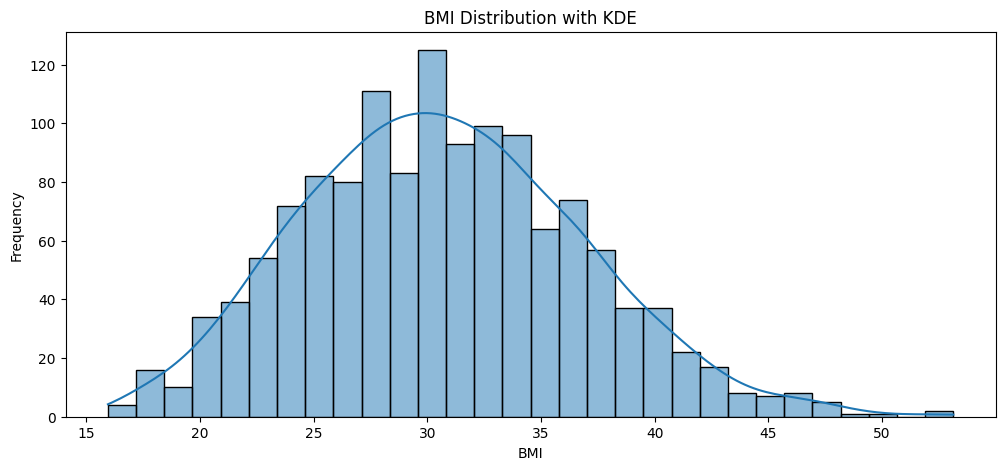

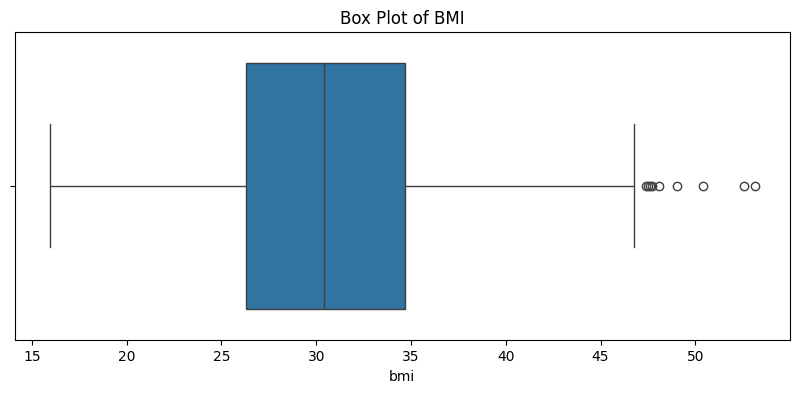

In [ ]:
# Outlier Analysis on Target Variable using histplot as distplot has been deprecated
plt.figure(figsize=(12, 5))

# Histogram with KDE for BMI
sns.histplot(df['bmi'], bins=30, kde=True) # KDE (Kernel Density Estimation)
plt.title("BMI Distribution with KDE")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

# Box plot to detect outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['bmi'])
plt.title("Box Plot of BMI")
plt.show()

In [ ]:
# Remove outliers
# Compute Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

# Compute IQR - IQR (Interquartile Range)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print the lower and upper bounds
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Remove outliers
df_cleaned = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

# Print the number of removed outliers
print(f"Outliers removed: {df.shape[0] - df_cleaned.shape[0]}")

# Display the first few rows of the cleaned dataset
df_cleaned.head()

Lower Bound: 13.7
Upper Bound: 47.290000000000006
Outliers removed: 9


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


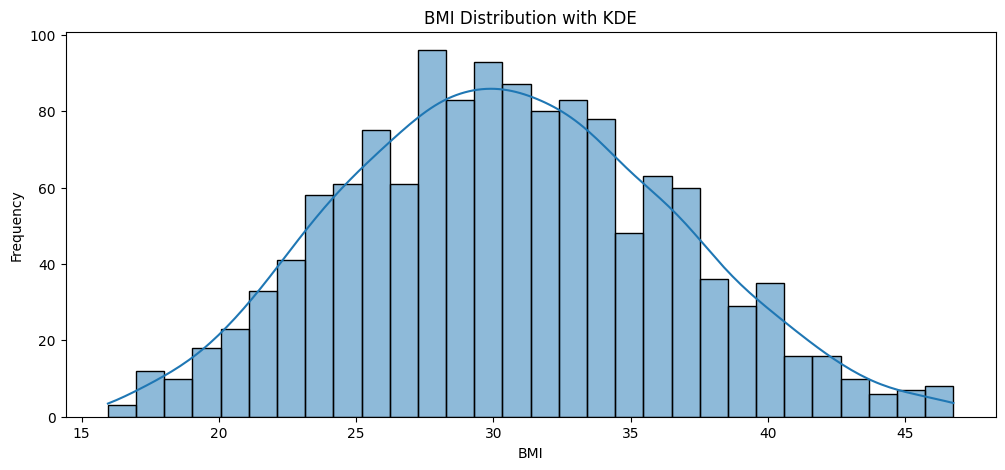

In [ ]:
# Outlier Analysis on Target Variable using histplot as distplot has been deprecated
plt.figure(figsize=(12, 5))

# Histogram with KDE for BMI
sns.histplot(df_cleaned['bmi'], bins=30, kde=True)
plt.title("BMI Distribution with KDE")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

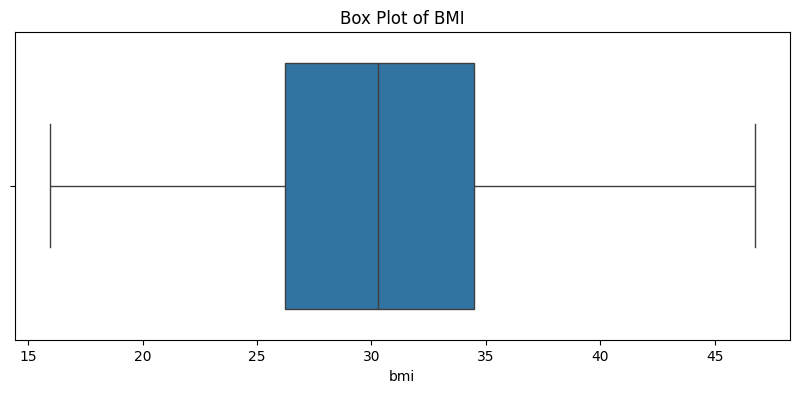

In [ ]:
# Box plot to detect outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_cleaned['bmi'])
plt.title("Box Plot of BMI")
plt.show()

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df_cleaned.corr()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
age,1.000000,0.114686,0.043041,0.302022,-0.019143,-0.024505,-0.000283,-0.011581,0.010474
bmi,0.114686,1.000000,0.017355,0.193196,0.039958,-0.002871,-0.128598,0.255863,0.000651
children,0.043041,0.017355,1.000000,0.069739,0.019281,0.007577,0.024209,-0.018816,0.020021
charges,0.302022,0.193196,0.069739,1.000000,0.063394,0.785912,-0.037704,0.071597,-0.045906
sex_male,-0.019143,0.039958,0.019281,0.063394,1.000000,0.079854,-0.009961,0.010263,-0.001195
smoker_yes,-0.024505,-0.002871,0.007577,0.785912,0.079854,1.000000,-0.035940,0.068270,-0.039440
region_northwest,-0.000283,-0.128598,0.024209,-0.037704,-0.009961,-0.035940,1.000000,-0.344807,-0.323046
region_southeast,-0.011581,0.255863,-0.018816,0.071597,0.010263,0.068270,-0.344807,1.000000,-0.344105
region_southwest,0.010474,0.000651,0.020021,-0.045906,-0.001195,-0.039440,-0.323046,-0.344105,1.000000


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, drop_first=True)

In [ ]:
df_cleaned

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


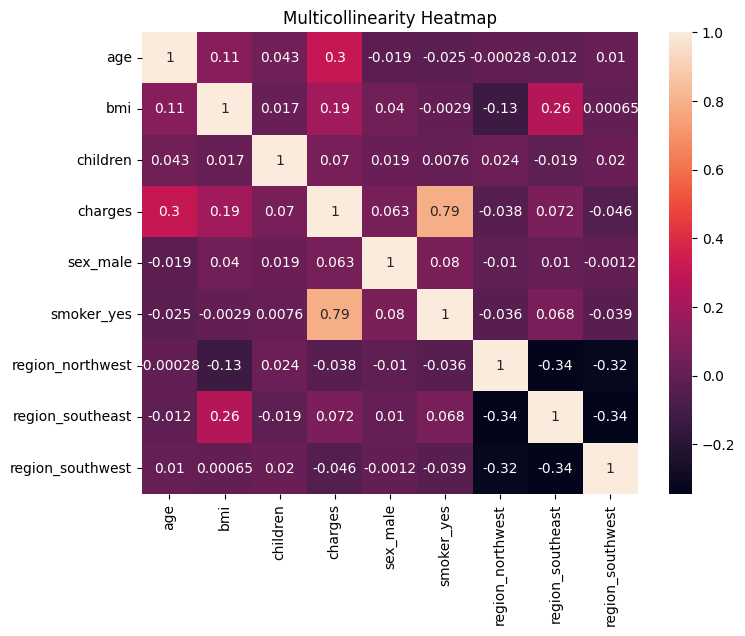

In [ ]:
# Convert categorical variables to numerical (if any exist)
df_cleaned = pd.get_dummies(df_cleaned, drop_first=True)

# Compute the correlation matrix
corr_matrix = df_cleaned.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)

# Title of the heatmap
plt.title("Multicollinearity Heatmap")

# Show the plot
plt.show()

In [ ]:
"""
Understanding the Heatmap:
Values close to +1 or -1 indicate strong correlations.

If two independent variables have high correlation (e.g., > 0.8 or < -0.8), multicollinearity may be an issue.

The charges column is the dependent variable, so we check correlations with it.
"""

'\nUnderstanding the Heatmap:\nValues close to +1 or -1 indicate strong correlations.\n\nIf two independent variables have high correlation (e.g., > 0.8 or < -0.8), multicollinearity may be an issue.\n\nThe charges column is the dependent variable, so we check correlations with it.\n'

In [ ]:
"""
2. Simple Linear Regression:
Select one independent variable (predictor) and one dependent variable (response).
Train a Simple Linear Regression model using the selected variables.
Visualize the regression line on a scatter plot to show the relationship between the predictor and response variable.
"""

'\n2. Simple Linear Regression:\nSelect one independent variable (predictor) and one dependent variable (response).\nTrain a Simple Linear Regression model using the selected variables.\nVisualize the regression line on a scatter plot to show the relationship between the predictor and response variable.\n'

In [ ]:
"""
Select bmi (X) as the predictor and charges (y) as the response.

Split the data into training and testing sets.

Train a Linear Regression model.

Plot a scatter plot with the regression line.

"""

'\nSelect bmi (X) as the predictor and charges (y) as the response.\n\nSplit the data into training and testing sets.\n\nTrain a Linear Regression model.\n\nPlot a scatter plot with the regression line.\n\n'

In [ ]:
# 2.1 Select independent (X) and dependent (y) variables
X = df_cleaned[['bmi']]  # Predictor
y = df_cleaned['charges']  # Response variable

# 2.2 Split data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 2.3 Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict charges
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [ ]:
# Model Evaluation R2
print('Testing R2 Score :', np.round(r2_score(y_test, y_pred), 2))
print('Training R2 Score :', np.round(r2_score(y_train, y_train_pred), 2))

Testing R2 Score : 0.06
Training R2 Score : 0.03


In [ ]:
# Model Evaluation RMSE
print('Training RMSE :', np.round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
print('Testing RMSE :', np.round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

Training RMSE : 11890.75
Testing RMSE : 11402.94


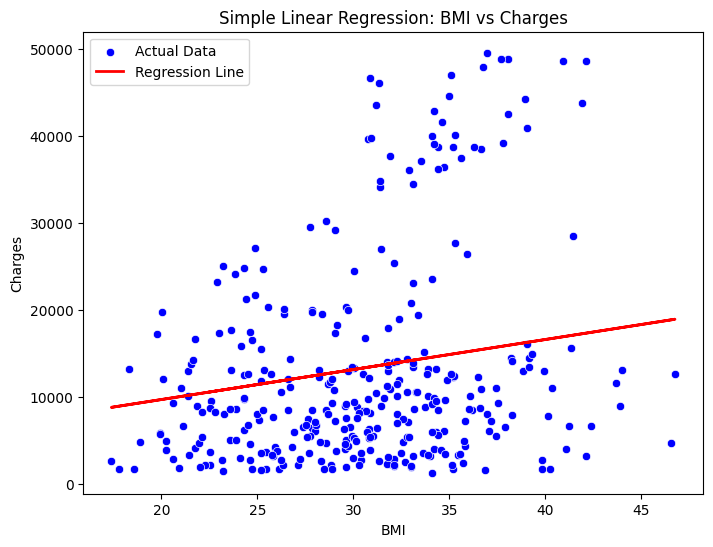

Intercept: 2770.1478199248522
Coefficient: 345.41293015829336


In [ ]:
# 2.4 Plot scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['bmi'], y=y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("Simple Linear Regression: BMI vs Charges")
plt.legend()
plt.show()

# Print model coefficients
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

In [ ]:
"""
3. Multiple Linear Regression:
Select multiple independent variables (predictors) and one dependent variable (response).
Train a Multiple Linear Regression model using the selected variables.
Analyze the regression coefficients to understand the impact of each predictor on the response variable.
"""

'\n3. Multiple Linear Regression:\nSelect multiple independent variables (predictors) and one dependent variable (response).\nTrain a Multiple Linear Regression model using the selected variables.\nAnalyze the regression coefficients to understand the impact of each predictor on the response variable.\n'

In [ ]:
# 1.2 Load the dataset for regression analysis.
##df = pd.read_csv('insurance.csv')
df_cleaned.head()



,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
#updates
df_cleaned.columns



Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [ ]:
X = df_cleaned[['age', 'bmi', 'children','sex_male','region_northwest', 'region_southeast', 'region_southwest']]
y = df_cleaned['charges']

In [ ]:
# Select independent variables (predictors)
X = df_cleaned[['age', 'bmi', 'children', 'smoker_yes']]  # Multiple predictors
y = df_cleaned['charges']  # Response variable

In [ ]:
# Split data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=75)

In [ ]:
# Train Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict charges
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [ ]:
# Analyze regression coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)


      Feature   Coefficient
0         age    257.721169
1         bmi    313.996779
2    children    491.562857
3  smoker_yes  23510.262818


In [ ]:
# Model Evaluation R2
print('Testing R2 Score :', np.round(r2_score(y_test, y_pred), 2))
print('Training R2 Score :', np.round(r2_score(y_train, y_train_pred), 2))

Testing R2 Score : 0.16
Training R2 Score : 0.11


In [ ]:
# Model Evaluation RMSE
print('Training RMSE :', np.round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 2))
print('Testing RMSE :', np.round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

Training RMSE : 6075.83
Testing RMSE : 5703.97


In [ ]:
df_cleaned

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [ ]:
for i in range(1,100):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=i)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  y_train_pred = model.predict(X_train)
  print(f'Testing R2 Score randonstate is {i} :', np.round(r2_score(y_test, y_pred), 2))
  print('Training R2 Score :', np.round(r2_score(y_train, y_train_pred), 2))


Testing R2 Score randonstate is 1 : 0.72
Training R2 Score : 0.76
Testing R2 Score randonstate is 2 : 0.73
Training R2 Score : 0.75
Testing R2 Score randonstate is 3 : 0.76
Training R2 Score : 0.74
Testing R2 Score randonstate is 4 : 0.75
Training R2 Score : 0.75
Testing R2 Score randonstate is 5 : 0.7
Training R2 Score : 0.77
Testing R2 Score randonstate is 6 : 0.76
Training R2 Score : 0.75
Testing R2 Score randonstate is 7 : 0.72
Training R2 Score : 0.76
Testing R2 Score randonstate is 8 : 0.74
Training R2 Score : 0.75
Testing R2 Score randonstate is 9 : 0.74
Training R2 Score : 0.75
Testing R2 Score randonstate is 10 : 0.7
Training R2 Score : 0.76
Testing R2 Score randonstate is 11 : 0.78
Training R2 Score : 0.74
Testing R2 Score randonstate is 12 : 0.78
Training R2 Score : 0.74
Testing R2 Score randonstate is 13 : 0.79
Training R2 Score : 0.74
Testing R2 Score randonstate is 14 : 0.76
Training R2 Score : 0.75
Testing R2 Score randonstate is 15 : 0.75
Training R2 Score : 0.75
Testin